In [17]:
import jax
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import immrax as irx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cvxpy as cp
import scipy
from immutabledict import immutabledict
from reach import *
from functools import partial
import control
from GPR import *
from TVGPR import *
from cyipopt import minimize_ipopt

# Some configurations
jax.config.update("jax_enable_x64", True)

# We wrap the jax.jit function t/o set the backend to cpu by default for convenience.
device = 'cpu'
def jit (*args, **kwargs):
    kwargs.setdefault('backend', device)
    return jax.jit(*args, **kwargs)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14
})

np.random.seed(0)

In [18]:
# system dynamics and initial conditions

class PlanarMultirotor (irx.System) :
    def __init__ (self) :
        self.xlen = 5
        self.evolution = 'continuous'

    def f(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        # u1, u2 = u.ravel()
        u1 = u[0]
        u2 = u[1]
        w1 = w[0]
        g = 9.81

        return jnp.array([
            vx,
            vy,
            -1*u1*jnp.sin(theta) + w1,
            u1*jnp.cos(theta) - g,
            u2
        ])
    
    def f_np(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        u1 = u[0]
        u2 = u[1]
        w1 = w[0]
        g = 9.81

        return np.array([
            vx,
            vy,
            -1*u1*np.sin(theta) + w1,
            u1*np.cos(theta) - g,
            u2
        ])

sys = PlanarMultirotor()

# initial conditions
x0 = jnp.array([2.5, 6., 0., 0., 0.1])
u0 = jnp.array([9.81, 0.1])

w0 = jnp.array([0.0])

# x0_buf = 0.05 * jnp.array([1.0, 1.0, 1.0, 1.0, 1.0])
x0_buf = jnp.array([0.01, 0.01, 0.01, 0.01, 0.01])*0.05
ix0 = irx.icentpert(x0, x0_buf)
print(ix0)

ulim = irx.interval([-15, -3],[15, 3])

actual_disturbance_GP = GPR(jnp.array([[-2,-0.66005468347438],[0,1.71910828159421],[2,-2.73909534657961],[4,3.76474225408493],[6,3.65733558594356],[8,-0.116994810217270],[10,2.40224375111040],[12,-2.86490929098228]]), sigma_f = 5.0, l=2.0, sigma_n = 0.01)
def actual_disturbance (t, x) :
    return actual_disturbance_GP.mean(jnp.array([x[1]])).reshape(-1)

obs = jnp.array([[x0[1], actual_disturbance(0.0, x0)[0]], 
                    [x0[1], actual_disturbance(0.0, x0)[0]], 
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]]])

# GP = GPR(jnp.array([[1., 1.], [2., 1.0], [0., 1.]]), sigma_f = 1.0, l=2.0, sigma_n = 0.01)
# GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 0.5], [2.0, 1.0]]))
# GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 0.5], [0.5, 1.], [0.75, 0.5], [0.25, 1.]]), l=1.)


# print(sigma_if(0.0, ix0))


[[( 2.4995e+00, 2.5005e+00)]
 [( 5.9995e+00, 6.0005e+00)]
 [(-5.0000e-04, 5.0000e-04)]
 [(-5.0000e-04, 5.0000e-04)]
 [( 9.9500e-02, 1.0050e-01)]]


In [19]:
# determinant helper function, can't use np.linalg.det because it uses a primitive not in immrax
def getDet(mat, n=5):
  
    # Base case: if the matrix is 1x1
    if n == 1:
        return mat[0][0]
    
    # Base case for 2x2 matrix
    if n == 2:
        return mat[0][0] * mat[1][1] - \
               mat[0][1] * mat[1][0]
    
    # Recursive case for larger matrices
    res = 0
    for col in range(n):
      
        # Create a submatrix by removing the first 
        # row and the current column
        sub = [[0] * (n - 1) for _ in range(n - 1)]
        for i in range(1, n):
            subcol = 0
            for j in range(n):
              
                # Skip the current column
                if j == col:
                    continue
                
                # Fill the submatrix
                sub[i - 1][subcol] = mat[i][j]
                subcol += 1
        
        # Cofactor expansion
        sign = 1 if col % 2 == 0 else -1
        res += sign * mat[0][col] * getDet(sub, n - 1)
    
    return res

In [20]:
# Get initial P, K from LQR

# linearize system around x0, u0
A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, [0]))(x0), jax.jacfwd(lambda u: sys.f(0, x0, u, [0]))(u0)
# print(A)
# print(B)

# weight matrices
Q = jnp.array([1, 1, 1, 1, 1]) * jnp.eye(sys.xlen)
R = jnp.array([1, 1]) * jnp.eye(2)

# LQR to get initial K, P
K, P, _ = control.lqr(A, B, Q, R)
feedback_K = -1 * K
print(feedback_K)

A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, [0]))(x0*0.0), jax.jacfwd(lambda u: sys.f(0, x0, u, [0]))(u0)
Q = jnp.array([2000, 20, 500, 500, 1]) * jnp.eye(sys.xlen)
R = jnp.array([1, 20]) * jnp.eye(2)
K, P, _ = control.lqr(A, B, Q, R)
backup_K = -1 * K
print(backup_K)

[[ 9.98334166e-02 -9.95004165e-01  1.72916550e-01 -1.72339777e+00
  -9.25998451e-16]
 [ 9.95004165e-01  9.98334166e-02  1.44427207e+00  1.44910564e-01
  -5.42944692e+00]]
[[  5.41218599  -4.43926598   2.97952048 -22.39365974  -1.3617038 ]
 [  9.9265005    0.12102016   6.94647172   0.62854492 -11.67249174]]


In [21]:
# Simulation parameters
t0 = 0.     # Initial time
dt = 0.05  # Time step

T = 2.0   # Horizon for one step of the algorithm, T = 0.689 is the limit before ellipsoids explode with K_limiting
tt = np.arange(t0, T+dt, dt)
# print(tt)
# T = 0.1
# N = 5       # Number of iterations of the algorithm
# tf = T*N    # Final time

sys_mjacM = irx.mjacM(sys.f)
sys_jacM = irx.jacM(sys.f)

perm = irx.Permutation((0, 1, 2, 3, 4, 5, 6, 7, 8))

# sigma_mjacM = irx.mjacM(sigma)
# sigma_jacM = irx.jacM(sigma)
# sigma_perm = irx.Permutation((0, 1, 3, 4, 5, 2))

# print(sigma(0.0, x0)) 

# sigma_if = lambda t, x : irx.icentpert(0.0, irx.natif(sigma)(t, x).upper)

# print(sigma_if(0.0, ix0))

# def upper_bound(t, x):
#     return GP.mean(jnp.array([x[1]])).reshape(-1) + sigma(t, x)#jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

# def lower_bound(t, x):
#     return GP.mean(jnp.array([x[1]])).reshape(-1) - sigma(t, x)#jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

# dist_if = lambda t, x : irx.interval(irx.natif(lower_bound)(t, x).lower, irx.natif(upper_bound)(t, x).upper)  
# test_interval = irx.icentpert(x0, jnp.array([1, 1, 1, 1, 1]))
# print(dist_if(0.0, test_interval))
# print(mean_disturbance(0.0, x0))
# print(dist_if(0.0, test_interval) - mean_disturbance(0.0, x0))

In [22]:
from itertools import product
# CBF CODE
@jit
def LSE(s, P):
    return (-1/P) * jnp.log(jnp.sum(jnp.exp(-P*s)))

def LSE_h(a, p=5):
    def h_fun(x):
        return -1*(10*(x[0]**2 - 0.0625) -  x[1])
        # return -1*(5*(x[0]**2 - 0.0625) -  x[1])
        # return jnp.maximum(-1*(5*(x[0]**2 - 0.0625) -  x[1]), x[3])
    h_arr = jnp.array([h_fun(ac) for ac in a])
    return LSE(h_arr, p)

# print(M_all)
sh_x = ix0.shape
ic_x = jnp.isclose(ix0.lower.reshape(-1), ix0.upper.reshape(-1))
cs_x = [irx.Corner(p) for p in product(*[(0,) if ic_x[i] else (0,1) for i in range(len(ic_x))])]
@jit
def gsc_x (ix) :
    ix = ix.reshape(-1)
    return [jnp.array([ix.lower[i] if ci == 0 else ix.upper[i] for i, ci in enumerate(c)]).reshape(sh_x) for c in cs_x]

# assumed single embedding state is input
@jit
def gamma(x):
    print(x)
    corners = gsc_x(irx.interval(x[0:5], x[5:]))
    print(len(corners))
    return LSE_h(corners)

@jit
def PHI(tt, xx):
    gamma_arr = jnp.array([gamma(x) for x in xx])
    return tt[jnp.argmax(gamma_arr)], jnp.max(gamma_arr)

gamma(irx.i2ut(ix0))

d_LSEh_func = lambda x : jax.jacfwd(gamma, argnums=(0,))(irx.i2ut(ix0))[0]
print(d_LSEh_func(x0))

Traced<ShapedArray(float64[10])>with<DynamicJaxprTrace(level=1/0)>
32
[-21.88679672   0.50125     -0.          -0.          -0.
 -28.11444681   0.49875     -0.          -0.          -0.        ]


In [23]:

@partial(jit, static_argnames=('mjacM',))
def rollout (ix, xc, K_feed, K_backup, obs, mjacM=True) :
    # mjacM=True
    def mean_disturbance (t, x) :
        return GP.mean(jnp.array([x[1]])).reshape(-1)
    
    def sigma(t, x):
        return jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

    def sigma_bruteforce_if(t, ix):
        div = 100
        x_list = [ix.lower + ((ix.upper - ix.lower)/div)*i for i in range(div)]
        sigma_list = 3.0*jnp.array([sigma(t, x) for x in x_list])
        return irx.interval(jnp.array([jnp.min(sigma_list)]), jnp.array([jnp.max(sigma_list)]))
    
    def step (carry, t) :
        xtut, xnomt, M, uM, wM, G, sig_range, MS, it, t_star, gamma_star, d_LSE, S_t, S_star = carry
        # uint = irx.icentpert(unomt, 1)
        # unomt = jnp.array([9.0 + 0.1*t, 0.1])
        xnom_backup = xnomt
        xnom_backup = xnom_backup.at[1].set(xnom_backup[1] - 4.0)
        # xnom_backup = xnom_backup.at[1].set(0.0)
        ubackup = (K_backup @ xnom_backup) + jnp.array([9.81, 0.0])

    
        unomt = jnp.array([jnp.minimum(jnp.maximum(ubackup[0], ulim.lower[0]), ulim.upper[0]),
            jnp.minimum(jnp.maximum(ubackup[1], ulim.lower[1]), ulim.upper[1])])
        # print(unomt)

        # test values
        # wnomt = jnp.array([0.0])
        # wint = irx.icentpert(wnomt, jnp.array([1.]))
        wnomt = GP.mean(jnp.array([xnomt[1]])).reshape(-1)
        # sigma_int = irx.icentpert(0.0, sigma(t, xnomt))
        # wint = irx.interval(wnomt) + sigma_if(t, irx.ut2i(xtut))
        # wint = dist_if(t, irx.ut2i(xtut))
        # w_diff = wint - wnomt

        # buffer sampled sigma bound with lipschitz constant to recover guarantee
        xint = irx.ut2i(xtut)
        x_div = (xint.upper - xint.lower)/(100*2)
        sigma_lip = MS @ x_div.T

        # w_diff = sigma_if(t, irx.ut2i(xtut)) 
        w_diff = sigma_bruteforce_if(t, irx.ut2i(xtut))
        w_diffint = irx.icentpert(0.0, w_diff.upper + sigma_lip.upper[1])
        wint = irx.interval(wnomt) + w_diffint

        


        if mjacM :
            Mt, Mx, Mu, Mw = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), ulim, wint,
                                centers=((jnp.array([0.]), xnomt, unomt, wnomt),), 
                                permutations=(perm,))[0]
            _, MG = G_mjacM(irx.interval(0.), irx.ut2i(xtut), 
                         centers=((jnp.array([0.]), xnomt),), 
                         permutations=(G_perm,))[0]
            # _, MS = sigma_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #              centers=((jnp.array([0.]), xnomt),), 
            #              permutations=(sigma_perm,))[0]
            # print(MG)
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx, Mu, Mw = sys_jacM(irx.interval(0.), irx.ut2i(xtut), ulim, wint)
            _, MG = G_jacM(irx.interval(0.), irx.ut2i(xtut))
            # _, MS = sigma_mjacM(irx.interval(0.), irx.ut2i(xtut))

        Mt = irx.interval(Mt)
        Mx = irx.interval(Mx)
        Mu = irx.interval(Mu)
        Mw = irx.interval(Mw)
        # MG = irx.interval(MG)

        # F = lambda t, x, u : (Mx + Mu@K)@(x - xnomt) + Mu@(unomt) + sys.f(0., xnomt, unomt) # not 100% sure about this
        
        # F = lambda t, x, u, w : (Mx + Mu@K)@(x - xnomt) + Mw@(w - wnomt) + sys.f(0., xnomt, unomt, wnomt) # without GP Jac
        F = lambda t, x, u, w: (Mx + Mu@K_feed + Mw@MG)@(x - xnomt) + Mw@w_diffint + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(0., xnomt, unomt, wnomt)
        xtutp1 = xtut + dt*embsys.E(irx.interval(jnp.array([0.])), xtut, unomt, wint)
        # print(xtutp1)
        # TODO: i don't think this is right, do the math to confirm but should be a good placeholder
        # embsysjac_1 = jnp.hstack(((Mx + Mu@K + Mw@MG).lower, jnp.zeros((5, 5))))
        # embsysjac_2 = jnp.hstack((jnp.zeros((5, 5)), (Mx + Mu@K + Mw@MG).upper))
        # embsysjac = jnp.vstack((embsysjac_1, embsysjac_2))
        embsysjac = jax.jacfwd(embsys.E, argnums=(1,))(irx.interval(jnp.array([0.])), xtutp1, unomt, wint)[0]
        S_t = S_t + dt*(embsysjac@S_t)

        new_gamma = gamma(xtutp1)
        g_index = jnp.argmax(jnp.array([gamma_star, new_gamma]))
        gamma_star = jnp.array([gamma_star, new_gamma])[g_index]
        t_star = jnp.array([t_star, t])[g_index]
        d_LSE = jnp.array([d_LSE, jax.jacfwd(gamma, argnums=(0,))(xtutp1)[0]])[g_index]
        S_star = jnp.array([S_star, S_t])[g_index]
        
        # MG = jax.jacfwd(mean_disturbance, argnums=(1,))(0., xnomt)[0][0]
        return ((xtutp1, xnomtp1, M|Mx, uM|Mu, wM|Mw, G|MG, sig_range|w_diff, MS, it + 1, t_star, gamma_star, d_LSE, S_t, S_star), (xtutp1, xnomtp1, unomt))
    # unomt = jnp.array(u0)
    GP = GPR(obs, sigma_f = 5.0, l=2.0, sigma_n = 0.01)
    tt = jnp.arange(0, T, dt)
    J0 = jax.jacfwd(sys.f, argnums=(1,))(0., xc, u0, w0)[0]
    Ju = jax.jacfwd(sys.f, argnums=(2,))(0., xc, u0, w0)[0]
    Jw = jax.jacfwd(sys.f, argnums=(3,))(0., xc, u0, w0)[0]
    G0 = jax.jacfwd(mean_disturbance, argnums=(1,))(0., xc)[0]
    sig0 = irx.icentpert(0.0, sigma(0.0, xc))

    G_mjacM = irx.mjacM(mean_disturbance)
    G_jacM = irx.jacM(mean_disturbance)
    G_perm = irx.Permutation((0, 1, 3, 4, 5, 2))

    MS0 = jax.jacfwd(sigma, argnums=(1,))(0., xc)[0]
    t_star = 0
    gamma_star = gamma(irx.i2ut(ix))
    S_t = jnp.vstack((jnp.eye(5), jnp.eye(5)))
    S_star = S_t
    d_LSE = d_LSEh_func(irx.i2ut(ix))
    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0), irx.interval(Ju), irx.interval(Jw), irx.interval(G0), sig0, irx.interval(MS0), 0, t_star, gamma_star, d_LSE, S_t, S_star), tt)
    # return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2], carry[3], carry[4], jnp.vstack((u0, xx[2])), carry[5], carry[6]
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), jnp.vstack(xx[2]), carry[9], carry[10], carry[11], carry[13]

# xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K, u_ref)
xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(ix0, x0, feedback_K, backup_K, obs)
print(xx.shape)
print(xxnom.shape)
print(unom_arr.shape)
print(t_star)
print(PHI_x)
print(d_LSE)
print(S_star)
print(d_LSE @ S_star)
print(d_LSE @ S_star @ sys.f_np(0., x0, u0, w0))
# print(M.shape)
# print(Mu.shape)
# print(Mw.shape)
# print(unom_arr.shape)
# print(G)
# if np.any(np.isnan(np.array(G.lower))) : raise ValueError("NaN in G")
# print(sig_range)
# print((Mw@G).shape)

(41, 10)
(41, 5)
(40, 2)
1.05
4.757223677134154
[ 0.21994124  0.57255708 -0.         -0.         -0.         -4.82779326
  0.42744292 -0.         -0.         -0.        ]
[[ 0.51619036  0.08508996  0.21996892  0.17581432 -0.64744282]
 [-0.29093458  0.65427906 -0.51972139  0.38271297  0.45505315]
 [-0.62422543  0.1058387  -0.3767092  -0.00554731  0.56594037]
 [-0.24932982 -0.43092079 -0.43476833 -0.0669527   0.61844018]
 [-0.08018394  0.03667331 -0.07566022  0.06030833 -0.00856474]
 [ 0.51566645  0.07572504  0.21593178  0.16608553 -0.62248026]
 [-0.28908218  0.64874552 -0.52107745  0.3734652   0.47641843]
 [-0.61677715  0.04301436 -0.37810775 -0.06105579  0.65916798]
 [-0.23320041 -0.46088641 -0.429566   -0.10911173  0.69097213]
 [-0.08030663  0.02735503 -0.07881387  0.05110883  0.01294451]]
[-2.66614224  0.30504372 -1.5143948  -0.38439773  3.3269922 ]
1.8346847261041546


In [24]:
xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(ix0, x0, feedback_K, backup_K, obs)
print(t_star)
print(d_LSE @ S_star @ sys.f_np(0., x0, [0.0, 0.0], w0))
print(PHI_x)

1.05
3.7709417208593985
4.757223677134154


In [25]:
# cvxpy solve for filtered u
def u_ASIF(u_desired, x, PHI, d_LSE, S_star, sys):

    u = cp.Variable((2,))
    d_PHI = np.array(d_LSE @ S_star)
    # print(d_PHI)
    # sys.f_np(0, x, u, np.array([0]))
    # print(d_PHI@sys.f_np(0, x, u, np.array([0])))
    cons = []
    cons.extend([d_PHI@sys.f_np(0, x, u, np.array([0])) >= -(PHI**3)])
    cons.extend([u <= np.array(ulim.upper), u >= np.array(ulim.lower)])
    prob = cp.Problem(cp.Minimize(cp.norm(u - u_desired)), cons)
    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
    return prob.status, u.value

u_ASIF(np.array([0., 0.]), x0, PHI_x, d_LSE, S_star, sys)

('optimal', array([-0., -0.]))

In [26]:
#timing analysis
for i in range(100):
    xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(ix0, x0, feedback_K, backup_K, obs)
    u_ASIF(np.array([0., 0.]), x0, PHI_x, d_LSE, S_star, sys)
    # gamma(xx[0])
    # PHI(tt, xx)

In [27]:
# forward rollout with resulting K
def fwd_rollout (sys, K_feed, xref, uref, T, dt) :
    def step (carry, ref) :
        xt = carry
        t, xr, unom = ref
        xt = xt + dt*sys.f(0., xt, unom + K_feed @ (xt - xr), actual_disturbance(t, xt))  
        return xt, xt
    tt = jnp.arange(0, T, dt)
    return jnp.vstack([x0, jax.lax.scan(step, (x0), (tt, xref, uref))[1]])

xa = fwd_rollout(sys, feedback_K, xxnom[:-1], unom_arr, T, dt)
print(xa)
uint = irx.interval([0, -1],[15, 1])
# for i in range(len(unom_arr)):
#     uapplied = unom_arr[i, :] + K@(xa[i, :] - xxnom[i, :])
#     print(uapplied)
#     if not np.all((uapplied > uint.lower) & (uapplied < uint.upper)):
#         raise ValueError("uapplied not in bounds")

[[ 2.50000000e+00  6.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e-01]
 [ 2.50000000e+00  6.00000000e+00  1.11354823e-01  2.22209675e-01
   2.50000000e-01]
 [ 2.50556774e+00  6.01111048e+00  1.76984276e-01  1.90838599e-01
   4.00000038e-01]
 [ 2.51441695e+00  6.02065241e+00  1.60416693e-01  1.67860559e-01
   5.50000104e-01]
 [ 2.52243779e+00  6.02904544e+00  6.75868667e-02  1.21663925e-01
   6.99872811e-01]
 [ 2.52581713e+00  6.03512864e+00 -1.08204047e-01  5.15830212e-02
   8.49539373e-01]
 [ 2.52040693e+00  6.03770779e+00 -3.75502268e-01 -4.80229128e-02
   9.98956772e-01]
 [ 2.50163182e+00  6.03530664e+00 -7.47314489e-01 -1.85427252e-01
   1.14812428e+00]
 [ 2.46426609e+00  6.02603528e+00 -1.24280646e+00 -3.73350588e-01
   1.29708725e+00]
 [ 2.40212577e+00  6.00736775e+00 -1.78579962e+00 -6.61227400e-01
   1.33916189e+00]
 [ 2.31283579e+00  5.97430638e+00 -2.33349246e+00 -9.79688466e-01
   1.18805014e+00]
 [ 2.19616117e+00  5.92532196e+00 -2.84150501e+00 -1.19040698e+00

In [28]:
def quadplot(xpos,ypos,rot,scale):
    ts=-.5*np.arange(np.pi,3/2*np.pi,.2)+.3
    xtemp=np.cos(ts)
    ytemp=np.sin(ts)*np.cos(ts)

    xs=np.hstack((.4*xtemp-1,-1,-1,1,1,.4*xtemp+1))
    ys=np.hstack((.3*ytemp+.4,.4,0,0,.4,.3*ytemp+.4))
    xs=scale*xs
    ys=scale*ys
    rotmat=np.array([[np.cos(rot),-np.sin(rot)],[np.sin(rot),np.cos(rot)]])
    # print(xs)
    newpos=rotmat@np.vstack((xs,ys))
    xs=newpos[0,:]+xpos
    ys=newpos[1,:]+ypos
    return xs,ys

quadplot(0, 0, 0, 1)

(array([-0.88179192, -0.92053227, -0.96006663, -1.        , -1.03993337,
        -1.07946773, -1.11820808, -1.15576734, -1.        , -1.        ,
         1.        ,  1.        ,  1.11820808,  1.07946773,  1.03993337,
         1.        ,  0.96006663,  0.92053227,  0.88179192,  0.84423266]),
 array([0.31530363, 0.34158725, 0.3701996 , 0.4       , 0.4298004 ,
        0.45841275, 0.48469637, 0.50760341, 0.4       , 0.        ,
        0.        , 0.4       , 0.31530363, 0.34158725, 0.3701996 ,
        0.4       , 0.4298004 , 0.45841275, 0.48469637, 0.50760341]))

0
[2.5 6.  0.  0.  0.1]
[-4.24096456  2.9999999 ]
[11.87126916 23.60064716]
0
[ 2.5         6.          0.20403381 -0.70148887  0.25      ]
[11.87203567  2.99999994]
[10.08962743 22.25010789]
1
[ 2.51020169  5.96492556  0.2400387  -0.61684073  0.39999999]
[10.08955004  2.99999997]
[10.64201098 20.54242196]
2
[ 2.52220363  5.93408352  0.2319811  -0.64268618  0.54999999]
[10.64228091  2.99999999]
[11.21554406 18.28963331]
3
[ 2.53380268  5.90194921  0.14704647 -0.6795459   0.69999999]
[11.21594361  2.99999998]
[12.09477371 15.43559969]
4
[ 2.541155    5.86797192 -0.01610482 -0.74112456  0.84999999]
[12.09524132  2.99999999]
[13.34856385 11.8705897 ]
5
[ 2.54034976  5.83091569 -0.26720065 -0.83249178  0.99999999]
[13.34892847  2.99999997]
[15.11371454  7.44896689]
6
[ 2.52698973  5.7892911  -0.62010781 -0.96236893  1.14999999]
[14.99999927  2.99999998]
[17.67881166  2.00503542]
7
[ 2.49598434  5.74117265 -1.08994671 -1.14650336  1.29999999]
[15.          2.00505147]
[22.49984266 -3.376914

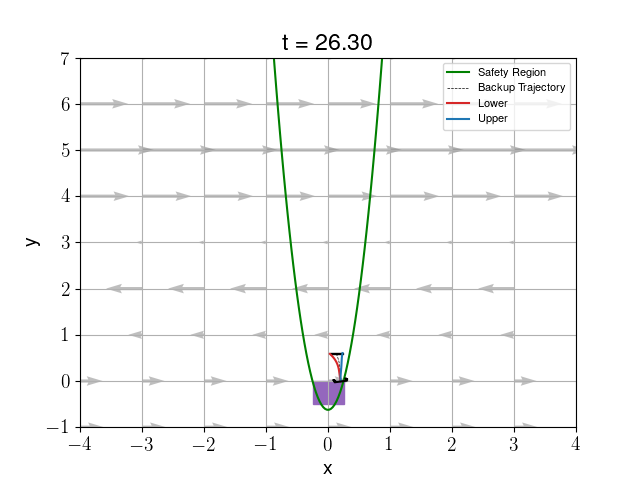

In [29]:
# RUN SIMULATION AND SAVE ANIMATION
import matplotlib.animation as animation

def u_desired(x):
    # sample desired input
    # return np.array([9.8, 0.0])
    return (backup_K @ x) + np.array([9.0, 0.0])

def u_backup(x): # make sure this matches what you used in rollout
    x = x.at[1].set(x[1] - 4.0)
    ubackup = (backup_K @ x) + np.array([9.81, 0.0])
    unomt = np.array([np.minimum(np.maximum(ubackup[0], ulim.lower[0]), ulim.upper[0]),
            np.minimum(np.maximum(ubackup[1], ulim.lower[1]), ulim.upper[1])])
    return unomt

current_state = x0
current_int = irx.icentpert(current_state, x0_buf)
current_time = 0.0
sim_dt = 0.05

obs = jnp.array([[x0[1], actual_disturbance(0.0, x0)[0]], 
                    [x0[1], actual_disturbance(0.0, x0)[0]], 
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]],
                    [x0[1], actual_disturbance(0.0, x0)[0]]])

xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(current_int, current_state, feedback_K, backup_K, obs)
desired_input = u_desired(current_state)
ASIF_status, applied_input = u_ASIF(desired_input, current_state, PHI_x, d_LSE, S_star, sys)
if ASIF_status != 'optimal':
    applied_input = u_backup(current_state)
flight_path = np.array([x0])


# PLOTTING
fig, ax = plt.subplots()
cbf_x = np.linspace(-1.5, 1.5, 100)
cbf_y = 10*(cbf_x**2 - 0.0625)
ax.plot(cbf_x, cbf_y, label='Safety Region', color='green')

arrow_points = np.mgrid[-4:4, -1:10].reshape(2, -1).T
arrow_dirs = arrow_points*0.0
for a in range(arrow_points.shape[0]):
    arrow_dirs[a, :] = [actual_disturbance(0.0, np.array([arrow_points[a, 0], arrow_points[a, 1], 0.0, 0.0, 0.0]))[0], 0.0]
ax.quiver(arrow_points[:, 0], arrow_points[:, 1], arrow_dirs[:, 0], arrow_dirs[:, 1], color='tab:gray', alpha=0.5)


# mixed monotonicity tube
# t_index = int(t_star/dt)
t_index = -1
nominal = ax.plot(xxnom[:t_index+1,0], xxnom[:t_index+1,1], label='Backup Trajectory', linestyle="dashed", color="black", linewidth=0.5)[0]
lower = ax.plot(xx[:t_index+1,0], xx[:t_index+1,1], label='Lower', color="tab:red")[0]
upper = ax.plot(xx[:t_index+1,5], xx[:t_index+1,6], label='Upper', color="tab:blue")[0]
# actual = ax.plot(xa[:t_index,0], xa[:t_index,1], label='Actual', linestyle="dashed")[0]
# flight = ax.plot(x0[0], x0[1], label='Flight Trajectory', color='black')[0]
start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1.0, edgecolor='black', facecolor='none', linestyle="solid")
start_patch = ax.add_patch(start_rect)
# end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:gray', facecolor='none', linestyle="dashed")
end_rect = Rectangle((xx[t_index,0], xx[t_index,1]), xx[t_index,5] - xx[t_index,0], xx[t_index,6] - xx[t_index,1], linewidth=1.0, edgecolor='black', facecolor='none', linestyle="solid")
end_patch = ax.add_patch(end_rect)
landing_rect = Rectangle((-0.25, -0.5), 0.5, 0.5, linewidth=1, edgecolor='tab:purple', facecolor='tab:purple')
ax.add_patch(landing_rect)
quad_x, quad_y = quadplot(x0[0], x0[1], x0[4], 0.1)
quad = ax.plot(quad_x, quad_y, color='black')[0]

plt.xlabel('x')
plt.ylabel('y')
titletime = plt.title('t = %1.2f' % current_time)
plt.legend(fontsize=8)
plt.grid()
# plt.gca().set_aspect('equal')
plt.gca().set_xlim([-4, 4])
plt.gca().set_ylim([-1, 7])

def update(frame):
    # apply input, update state/time
    global current_state, applied_input, current_time, flight_path, obs
    print(frame)
    print(current_state)
    print(applied_input)
    # while current_time < current_time + sim_dt:
    current_state = current_state + sim_dt * sys.f_np(0., current_state, applied_input, actual_disturbance(current_time, current_state))
    flight_path = np.vstack((flight_path, current_state))
    current_int = irx.icentpert(current_state, x0_buf)
    current_time = current_time + sim_dt
    
    # calculate new input
    xx, xxnom, unom_arr, t_star, PHI_x, d_LSE, S_star = rollout(current_int, current_state, feedback_K, backup_K, obs)
    # xa = fwd_rollout(sys, feedback_K, xxnom[:-1], unom_arr, T, dt)
    desired_input = u_desired(current_state)
    print(desired_input)
    ASIF_status, applied_input = u_ASIF(desired_input, current_state, PHI_x, d_LSE, S_star, sys)
    if ASIF_status != 'optimal':
        print("NOT OPTIMAL")
        applied_input = u_backup(current_state)
    

    # update plots
    t_index = int(t_star/dt)
    # t_index = -1
    if PHI_x < 0 or ASIF_status != 'optimal': #if hyperrectangle is too large or convex problem failed, collect observations
        obs = np.vstack((obs[1:, :], np.array([current_state[1], actual_disturbance(current_time, current_state)[0]])))

    lower.set_data(xx[:t_index+1,0], xx[:t_index+1,1])
    upper.set_data(xx[:t_index+1,5], xx[:t_index+1,6])
    nominal.set_data(xxnom[:t_index+1,0], xxnom[:t_index+1,1])

    quad_x, quad_y = quadplot(current_state[0], current_state[1], current_state[4], 0.1)
    quad.set_data(quad_x, quad_y)

    # actual.set_data(xa[:t_index,0], xa[:t_index,1])
    # flight.set_data(flight_path[:,0], flight_path[:,1])
    start_patch.set_xy((xx[0,0], xx[0,1]))
    start_patch.set_width(xx[0,5] - xx[0,0])
    start_patch.set_height(xx[0,6] - xx[0,1])
    end_patch.set_xy((xx[t_index,0], xx[t_index,1]))
    end_patch.set_width(xx[t_index,5] - xx[t_index,0])
    end_patch.set_height(xx[t_index,6] - xx[t_index,1])
    titletime.set_text('t = %1.2f' % current_time)
    return (lower, upper, nominal, start_patch, end_patch, titletime)

ani = animation.FuncAnimation(fig=fig, func=update, frames=525, interval=int(sim_dt*1000))
ani.save(filename="iasif_sim_test.gif", writer="pillow")

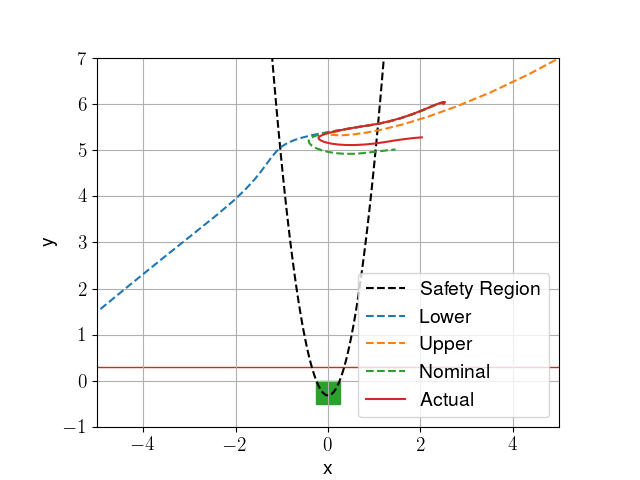

In [30]:
%matplotlib ipympl

import shapely.ops as so

# plot trajectories
fig, ax = plt.subplots()

cbf_x = np.linspace(-1.5, 1.5, 100)
cbf_y = 5*(cbf_x**2 - 0.0625)
ax.plot(cbf_x, cbf_y, label='Safety Region', linestyle="dashed", color='black')

# mixed monotonicity tube
ax.plot(xx[:,0], xx[:,1], label='Lower', linestyle="dashed")
ax.plot(xx[:,5], xx[:,6], label='Upper', linestyle="dashed")
ax.plot(xxnom[:,0], xxnom[:,1], label='Nominal', linestyle="dashed")
ax.plot(xa[:,0], xa[:,1], label='Actual')
start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)
landing_rect = Rectangle((-0.25, -0.5), 0.5, 0.5, linewidth=1, edgecolor='tab:green', facecolor='tab:green')
ax.add_patch(landing_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], ec='tab:red')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.gca().set_aspect('equal')
plt.gca().set_xlim([-5, 5])
plt.gca().set_ylim([-1, 7])
plt.show()




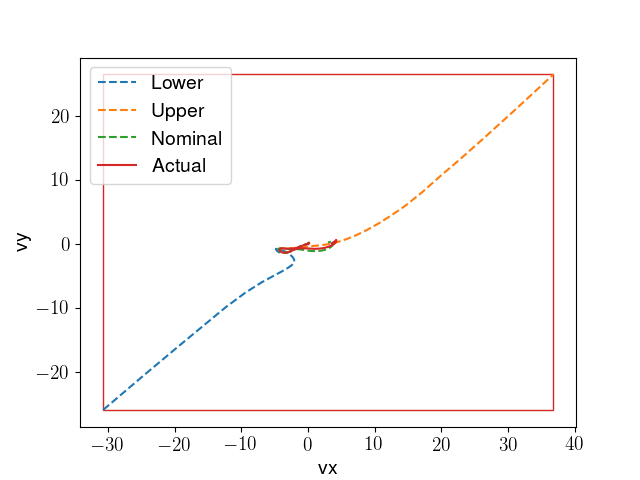

In [31]:
# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,2], xx[:,3], label='Lower', linestyle="dashed")
plt.plot(xx[:,7], xx[:,8], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,2], xxnom[:,3], label='Nominal', linestyle="dashed")
plt.plot(xa[:,2], xa[:,3], label='Actual')
start_rect = Rectangle((xx[0,2], xx[0,3]), xx[0,7] - xx[0,2], xx[0,8] - xx[0,3], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,2], xx[-1,3]), xx[-1,7] - xx[-1,2], xx[-1,8] - xx[-1,3], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], 2, 3, ec='tab:red')

plt.xlabel('vx')
plt.ylabel('vy')
plt.legend()
plt.show()




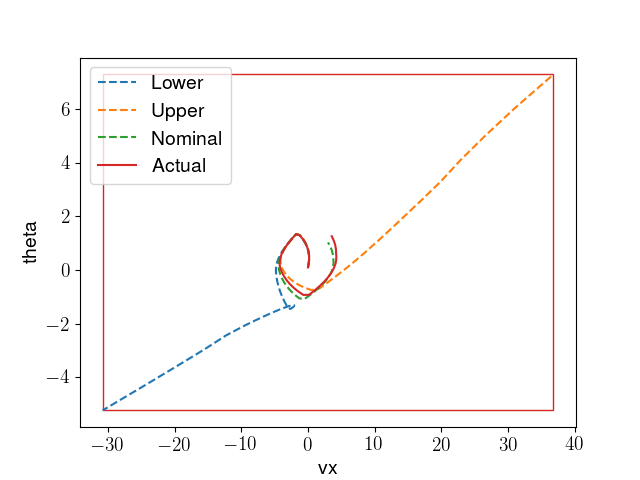

In [32]:
# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,2], xx[:,4], label='Lower', linestyle="dashed")
plt.plot(xx[:,7], xx[:,9], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,2], xxnom[:,4], label='Nominal', linestyle="dashed")
plt.plot(xa[:,2], xa[:,4], label='Actual')
start_rect = Rectangle((xx[0,2], xx[0,4]), xx[0,7] - xx[0,2], xx[0,9] - xx[0,4], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,2], xx[-1,4]), xx[-1,7] - xx[-1,2], xx[-1,9] - xx[-1,4], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], 2, 4, ec='tab:red')

plt.xlabel('vx')
plt.ylabel('theta')
plt.legend()
plt.show()


